In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


def f(x, y):
    """Целевая функция."""
    return x**3 - 12*x**2 + 45*x + y**3 + 4*y**2 + 4*y - 54


def grad(x, y):
    """Градиент целевой функции."""
    return np.array([3*x**2 - 24*x + 45, 3*y**2 + 8*y + 4])


def hessian(x, y):
    """Гессиан целевой функции."""
    return np.array([[6*x - 24, 0], [0, 6*y + 8]])


## ДЗ2.2: Аналитическое решение

Нахождение стационарных точек функции $z(x,y) = x^3 - 12x^2 + 45x + y^3 + 4y^2 + 4y - 54$
и их классификация через анализ собственных значений Гессиана.


In [7]:
def analytical_solution():
    """Находит и классифицирует все стационарные точки."""
    x_roots = [3, 5]
    y_roots = [-2/3, -2]
    points = [(x, y) for x in x_roots for y in y_roots]

    print("=" * 60)
    print("ДЗ2.2 — Аналитическое исследование стационарных точек")
    print("=" * 60)
    print()
    print("Частные производные:")
    print("  dz/dx = 3x\u00b2 - 24x + 45 = 3(x - 3)(x - 5)")
    print("  dz/dy = 3y\u00b2 + 8y + 4 = (3y + 2)(y + 2)")
    print()
    print("Корни: x \u2208 {3, 5},  y \u2208 {-2/3, -2}")
    print()
    print("Гессиан: H = diag(6x - 24, 6y + 8) — диагональная матрица")
    print("  => собственные значения: \u03bb\u2081 = 6x - 24, \u03bb\u2082 = 6y + 8")
    print()
    header = f"{'Точка':>15} | {'\u03bb\u2081':>6} | {'\u03bb\u2082':>6} | {'Тип':20} | {'f(x,y)':>12}"
    print(header)
    print("-" * 75)

    for x0, y0 in points:
        lam1 = 6*x0 - 24
        lam2 = 6*y0 + 8
        val = f(x0, y0)

        if lam1 > 0 and lam2 > 0:
            etype = "Локальный минимум"
        elif lam1 < 0 and lam2 < 0:
            etype = "Локальный максимум"
        else:
            etype = "Седловая точка"

        print(f"({x0:>4}, {y0:>8.4f}) | {lam1:>+5} | {lam2:>+5} | {etype:<20} | {val:>12.6f}")

    print()
    print("Вывод: глобальный минимум в точке (5, -2/3) \u2248 (5, -0.6667).")
    print(f"  f_min = f(5, -2/3) = {f(5, -2/3):.6f}")
    print()


In [8]:
def goldensection(f_obj, x, direction, alpha_max=100.0, tol=1e-9):
    """
    Поиск шага α, минимизирующего φ(α) = f(x + α·direction).
    Метод золотого сечения с предварительной локализацией минимума.
    """
    phi = (np.sqrt(5) - 1) / 2

    def phi_fn(alpha):
        return f_obj(*(x + alpha * direction))

    # Локализация: ищем интервал [a, b], содержащий минимум
    a, fa = 0.0, phi_fn(0.0)
    b = 1.0
    fb = phi_fn(b)

    if fb < fa:
        while True:
            c = 2.0 * b
            fc = phi_fn(c)
            if fc > fb or c > alpha_max:
                break
            a, fa = b, fb
            b, fb = c, fc
        alpha_lo, alpha_hi = a, c
    else:
        alpha_lo, alpha_hi = a, b

    # Золотое сечение
    c = alpha_hi - phi * (alpha_hi - alpha_lo)
    d = alpha_lo + phi * (alpha_hi - alpha_lo)
    fc, fd = phi_fn(c), phi_fn(d)

    for _ in range(200):
        if abs(alpha_hi - alpha_lo) < tol * (abs(c) + abs(d)):
            break
        if fc < fd:
            alpha_hi = d
            d, fd = c, fc
            c = alpha_hi - phi * (alpha_hi - alpha_lo)
            fc = phi_fn(c)
        else:
            alpha_lo = c
            c, fc = d, fd
            d = alpha_lo + phi * (alpha_hi - alpha_lo)
            fd = phi_fn(d)

    return (alpha_lo + alpha_hi) / 2.0


def optimize(method, x0, y0, f, grad, hessian=None,
             max_iter=2000, eps=1e-4, **kwargs):
    """
    Запуск метода оптимизации с записью истории.
    Возвращает dict: {номер_итерации: {solution: ndarray, objective: float}}.
    """
    x, y = x0, y0
    history = {0: {"solution": np.array([x, y]), "objective": f(x, y)}}
    g_prev, d_prev = None, None

    for k in range(1, max_iter + 1):
        g = grad(x, y)

        if np.linalg.norm(g) < eps:
            break

        if method == "gradient_descent":
            d = -g
            alpha = kwargs.get("alpha", 0.05)
            x_new = x + alpha * d[0]
            y_new = y + alpha * d[1]

        elif method == "steepest_descent":
            d = -g
            alpha = goldensection(f, np.array([x, y]), d)
            x_new = x + alpha * d[0]
            y_new = y + alpha * d[1]

        elif method == "conjugate_gradient":
            if d_prev is None:
                d = -g
            else:
                beta = np.dot(g, g) / np.dot(g_prev, g_prev)
                d = -g + beta * d_prev
            alpha = goldensection(f, np.array([x, y]), d)
            x_new = x + alpha * d[0]
            y_new = y + alpha * d[1]
            g_prev = g.copy()
            d_prev = d.copy()

        elif method == "newton":
            H = hessian(x, y)
            d = -np.linalg.solve(H, g)
            x_new = x + d[0]
            y_new = y + d[1]

        else:
            raise ValueError(f"Unknown method: {method}")

        x, y = x_new, y_new
        history[k] = {
            "solution": np.array([x, y]),
            "objective": f(x, y)
        }

    return history


In [9]:
def plot_history(title, objective, bounds, step_x, step_y, history, save_path=None):
    """
    Строит линии уровня и ломаную последовательных приближений.
    Линии уровня проходят строго через вершины ломаной (ДЗ2.1).
    Стиль оформления — по образцу Contours and solutions.ipynb.
    """
    xaxis_vals = np.arange(bounds[0, 0], bounds[0, 1] + step_x, step_x)
    yaxis_vals = np.arange(bounds[1, 0], bounds[1, 1] + step_y, step_y)
    xx, yy = np.meshgrid(xaxis_vals, yaxis_vals)
    target_grid_vals = objective(xx, yy)

    # Уровни = значения целевой функции в точках приближений
    levels = sorted(set(round(info["objective"], 10) for info in history.values()))

    colorlist = ["darkblue", "blue", "aqua", "lawngreen",
                 "gold", "darkorange", "brown"]
    newcmp = LinearSegmentedColormap.from_list("testCmap", colors=colorlist, N=256)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    xmin, xmax, ymin, ymax = np.amin(xx), np.amax(xx), np.amin(yy), np.amax(yy)

    contours = ax.contour(xx, yy, target_grid_vals, levels=levels,
                          cmap=newcmp, alpha=0.4)
    plt.clabel(contours, inline=1, fontsize=8)

    solutions_x = [v["solution"][0] for k, v in history.items()]
    solutions_y = [v["solution"][1] for k, v in history.items()]
    plt.plot(solutions_x, solutions_y, ".-", color="r")

    plt.title(title)
    ax.set_xlim([xmin, xmax])
    ax.set_ylim([ymin, ymax])

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

## Выполнение заданий

Запуск аналитического решения (ДЗ2.2), численного решения методом Ньютона (ДЗ2.2)
и визуализация всех четырёх методов оптимизации (ДЗ2.1).


ДЗ2.2 — Аналитическое исследование стационарных точек

Частные производные:
  dz/dx = 3x² - 24x + 45 = 3(x - 3)(x - 5)
  dz/dy = 3y² + 8y + 4 = (3y + 2)(y + 2)

Корни: x ∈ {3, 5},  y ∈ {-2/3, -2}

Гессиан: H = diag(6x - 24, 6y + 8) — диагональная матрица
  => собственные значения: λ₁ = 6x - 24, λ₂ = 6y + 8

          Точка |     λ₁ |     λ₂ | Тип                  |       f(x,y)
---------------------------------------------------------------------------
(   3,  -0.6667) |    -6 |  +4.0 | Седловая точка       |    -1.185185
(   3,  -2.0000) |    -6 |    -4 | Локальный максимум   |     0.000000
(   5,  -0.6667) |    +6 |  +4.0 | Локальный минимум    |    -5.185185
(   5,  -2.0000) |    +6 |    -4 | Седловая точка       |    -4.000000

Вывод: глобальный минимум в точке (5, -2/3) ≈ (5, -0.6667).
  f_min = f(5, -2/3) = -5.185185

ДЗ2.2 — Численное решение методом Ньютона

Начальная точка: (4.5, -0.5)
Порог ||grad|| < 1e-4

  k |          x |          y |       f(x,y) |     ||grad||
---------

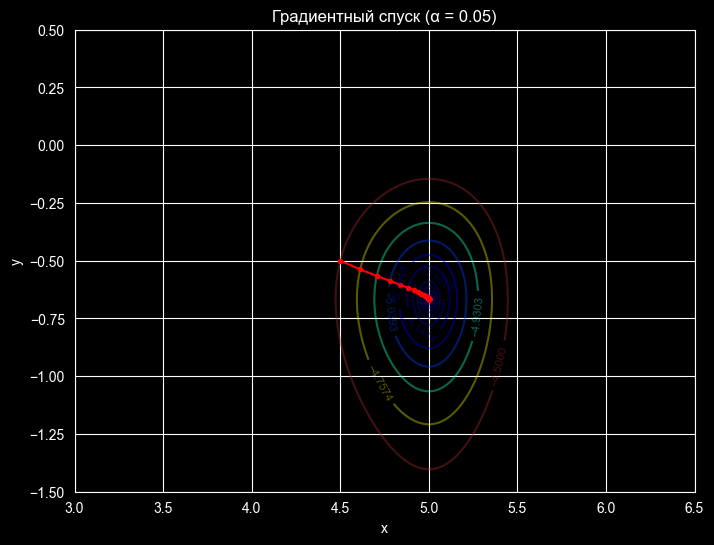

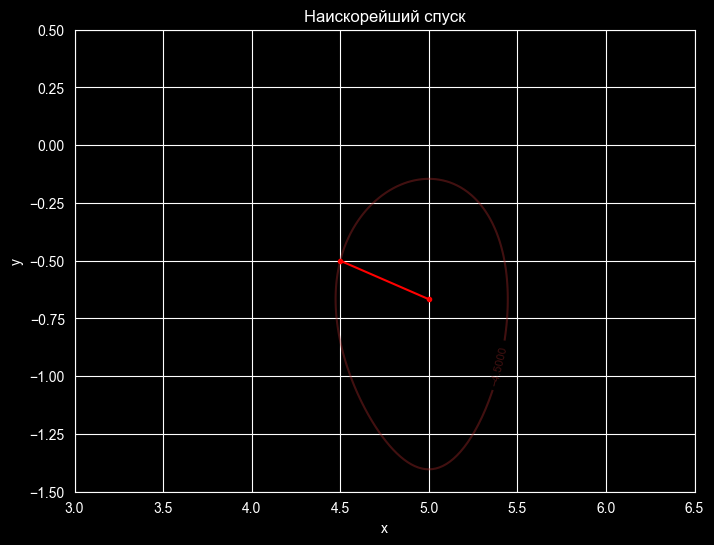

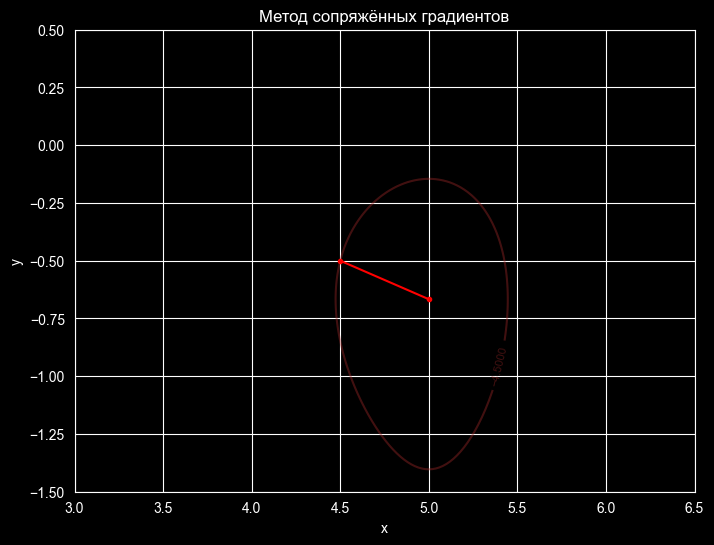

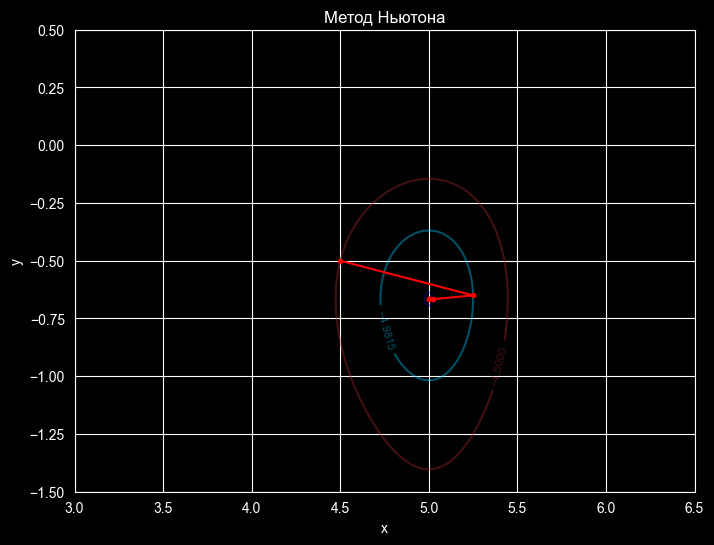

In [10]:
# --- ДЗ2.2: аналитическое решение ---
analytical_solution()

# --- Параметры ---
x0, y0 = 4.5, -0.5
bounds = np.array([[3.0, 6.5], [-1.5, 0.5]])
steps = (0.02, 0.02)

# --- ДЗ2.2: численное решение методом Ньютона ---
print("=" * 60)
print("ДЗ2.2 — Численное решение методом Ньютона")
print("=" * 60)
print()

history_newton = optimize("newton", x0, y0, f, grad, hessian, eps=1e-4)
print(f"Начальная точка: ({x0}, {y0})")
print("Порог ||grad|| < 1e-4")
print()
hdr = f"{'k':>3} | {'x':>10} | {'y':>10} | {'f(x,y)':>12} | {'||grad||':>12}"
print(hdr)
print("-" * 65)

for k, v in history_newton.items():
    sol = v["solution"]
    g_norm = np.linalg.norm(grad(*sol))
    print(f"{k:>3} | {sol[0]:>10.6f} | {sol[1]:>10.6f} | "
          f"{v['objective']:>12.6f} | {g_norm:>12.6f}")

final = history_newton[max(history_newton.keys())]
print()
print(f"Найденный минимум: x* = ({final['solution'][0]:.6f}, "
      f"{final['solution'][1]:.6f})")
print(f"f(x*) = {final['objective']:.6f}")
print("Аналитический минимум: (5, -2/3) \u2248 (5, -0.6667)")
print(f"f_min = {f(5, -2/3):.6f}")
print()

# --- ДЗ2.1: визуализация для каждого метода ---
print("=" * 60)
print("ДЗ2.1 — Визуализация методов оптимизации")
print("=" * 60)
print()

methods = [
    ("gradient_descent", "Градиентный спуск (\u03b1 = 0.05)",
     {"alpha": 0.05}),
    ("steepest_descent", "Наискорейший спуск", {}),
    ("conjugate_gradient", "Метод сопряжённых градиентов", {}),
    ("newton", "Метод Ньютона", {}),
]

for method_name, title, kw in methods:
    history = optimize(method_name, x0, y0, f, grad, hessian,
                       max_iter=2000, eps=1e-4, **kw)
    n = len(history) - 1
    sol = history[n]["solution"]
    print(f"  {title}: {n} итераций, "
          f"точка = ({sol[0]:.6f}, {sol[1]:.6f}), "
          f"f = {history[n]['objective']:.6f}")

print()
print("Строим графики...")

for method_name, title, kw in methods:
    history = optimize(method_name, x0, y0, f, grad, hessian,
                       max_iter=2000, eps=1e-4, **kw)
    plot_history(title, f, bounds, *steps, history)
